<a href="https://colab.research.google.com/github/ritabrezznica/DeepLearning/blob/main/BigData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install PySpark and dataset fetcher
!pip install pyspark ucimlrepo openpyxl mlxtend -q

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# After mounting, upload the dataset to your Drive and update this path:
# The dataset is an Excel file with two sheets: Year 2009-2010 and Year 2010-2011
import pandas as pd

FILE_PATH = '/content/drive/MyDrive/online_retail_II.xlsx'  # adjust if needed

df_2009 = pd.read_excel(FILE_PATH, sheet_name='Year 2009-2010', engine='openpyxl')
df_2010 = pd.read_excel(FILE_PATH, sheet_name='Year 2010-2011', engine='openpyxl')

df_pd = pd.concat([df_2009, df_2010], ignore_index=True)
print("Shape:", df_pd.shape)
df_pd.head()

Mounted at /content/drive
Shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder \
    .appName("OnlineRetailII") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

df = spark.createDataFrame(df_pd)
df.printSchema()
df.show(5)

root
 |-- Invoice: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: long (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- Price: double (nullable = true)
 |-- Customer ID: double (nullable = true)
 |-- Country: string (nullable = true)

+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|Price|Customer ID|       Country|
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
| 489434|    85048|15CM CHRISTMAS GL...|      12|2009-12-01 07:45:00| 6.95|    13085.0|United Kingdom|
| 489434|   79323P|  PINK CHERRY LIGHTS|      12|2009-12-01 07:45:00| 6.75|    13085.0|United Kingdom|
| 489434|   79323W| WHITE CHERRY LIGHTS|      12|2009-12-01 07:45:00| 6.75|    13085.0|United Kingdom|
| 489434|    22041|RECORD FRAME 7" S...|      48|2

In [5]:
# Step 1: Drop rows with null CustomerID or Description
df = df.dropna(subset=['Customer ID', 'Description'])

# Step 2: Remove cancelled orders (Invoice starting with 'C')
df = df.filter(~F.col('Invoice').startswith('C'))

# Step 3: Remove rows with non-positive Quantity or Price
df = df.filter((F.col('Quantity') > 0) & (F.col('Price') > 0))

# Step 4: Remove duplicates
df = df.dropDuplicates()

# Step 5: Cast types
df = df.withColumn('Customer ID', F.col('Customer ID').cast('int'))
df = df.withColumn('InvoiceDate', F.to_timestamp('InvoiceDate'))

# Step 6: Derive new time fields
df = df \
    .withColumn('Year', F.year('InvoiceDate')) \
    .withColumn('Month', F.month('InvoiceDate')) \
    .withColumn('DayOfWeek', F.dayofweek('InvoiceDate')) \
    .withColumn('Hour', F.hour('InvoiceDate'))

# Step 7: Derive TotalPrice per line
df = df.withColumn('TotalPrice', F.col('Quantity') * F.col('Price'))

print("Cleaned shape:", df.count(), len(df.columns))
df.show(5)

Cleaned shape: 779425 13
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+----+-----+---------+----+------------------+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|Price|Customer ID|       Country|Year|Month|DayOfWeek|Hour|        TotalPrice|
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+----+-----+---------+----+------------------+
| 489519|    82483|WOOD 2 DRAWER CAB...|       3|2009-12-01 11:37:00| 5.95|      17700|United Kingdom|2009|   12|        3|  11|             17.85|
| 489522|    21916|SET 12 RETRO WHIT...|       3|2009-12-01 11:45:00| 0.42|      15998|United Kingdom|2009|   12|        3|  11|              1.26|
| 489522|    22302|COFFEE MUG PEARS ...|       3|2009-12-01 11:45:00| 2.55|      15998|United Kingdom|2009|   12|        3|  11|7.6499999999999995|
| 489522|    10135|COLOURING PENCILS...|       6|2009-12-01 11:45:00| 1.25|      15998|

In [6]:
# Basic statistics
df.select('Quantity', 'Price', 'TotalPrice').describe().show()

# Unique counts
print("Unique Customers:", df.select('Customer ID').distinct().count())
print("Unique Products:", df.select('StockCode').distinct().count())
print("Unique Invoices:", df.select('Invoice').distinct().count())
print("Date range:", df.agg(F.min('InvoiceDate'), F.max('InvoiceDate')).show())

+-------+------------------+------------------+------------------+
|summary|          Quantity|             Price|        TotalPrice|
+-------+------------------+------------------+------------------+
|  count|            779425|            779425|            779425|
|   mean|13.489369727683869| 3.218487985367935| 22.29182316195837|
| stddev|145.85581409977826|29.676139695711434|227.42707548357194|
|    min|                 1|             0.001|             0.001|
|    max|             80995|           10953.5|          168469.6|
+-------+------------------+------------------+------------------+

Unique Customers: 5878
Unique Products: 4631
Unique Invoices: 36969
+-------------------+-------------------+
|   min(InvoiceDate)|   max(InvoiceDate)|
+-------------------+-------------------+
|2009-12-01 07:45:00|2011-12-09 12:50:00|
+-------------------+-------------------+

Date range: None


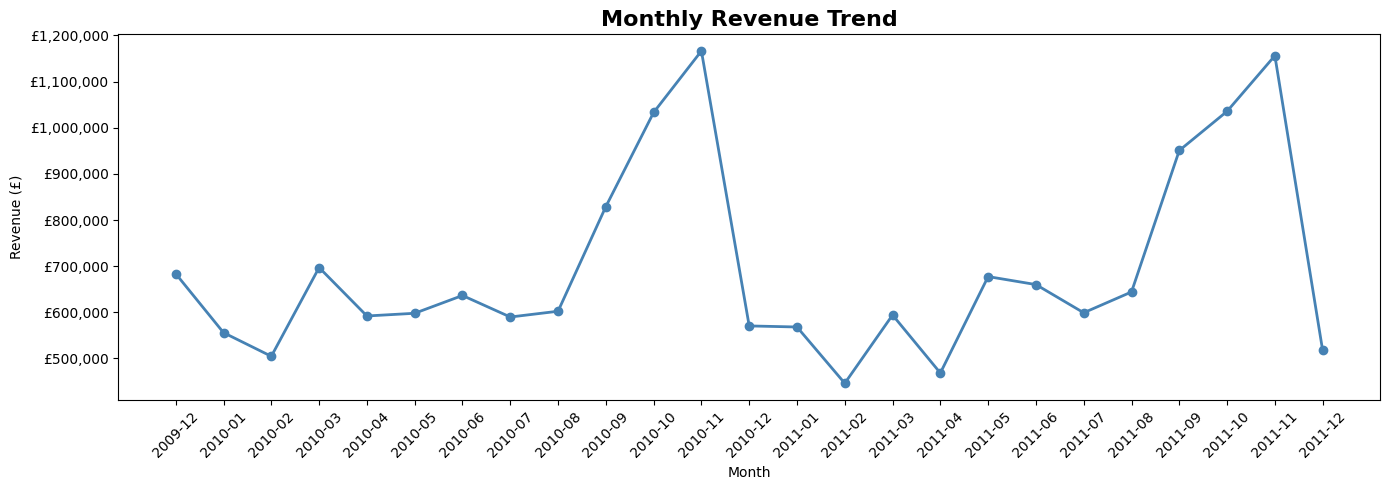

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

monthly = df.groupBy('Year', 'Month') \
    .agg(F.sum('TotalPrice').alias('Revenue')) \
    .orderBy('Year', 'Month') \
    .toPandas()

monthly['Period'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['Period'], monthly['Revenue'], marker='o', color='steelblue', linewidth=2)
ax.set_title('Monthly Revenue Trend', fontsize=16, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/monthly_revenue.png', dpi=150)
plt.show()

/tmp/ipykernel_4236/987336713.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, y='Description', x='Revenue', palette='Blues_r', ax=ax)


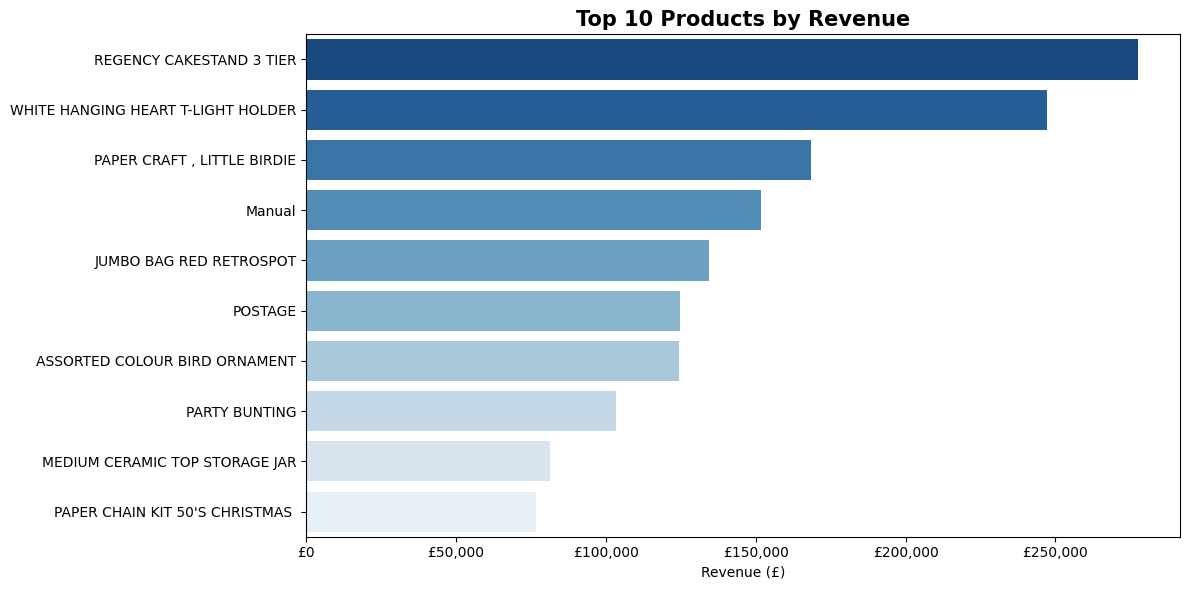

In [8]:
import seaborn as sns

top_products = df.groupBy('Description') \
    .agg(F.sum('TotalPrice').alias('Revenue')) \
    .orderBy(F.desc('Revenue')) \
    .limit(10) \
    .toPandas()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_products, y='Description', x='Revenue', palette='Blues_r', ax=ax)
ax.set_title('Top 10 Products by Revenue', fontsize=15, fontweight='bold')
ax.set_xlabel('Revenue (£)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/top_products.png', dpi=150)
plt.show()

/tmp/ipykernel_4236/337736871.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dow, x='DayName', y='Orders', palette='viridis', ax=axes[0])
/tmp/ipykernel_4236/337736871.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hour_df, x='Hour', y='Orders', palette='rocket', ax=axes[1])


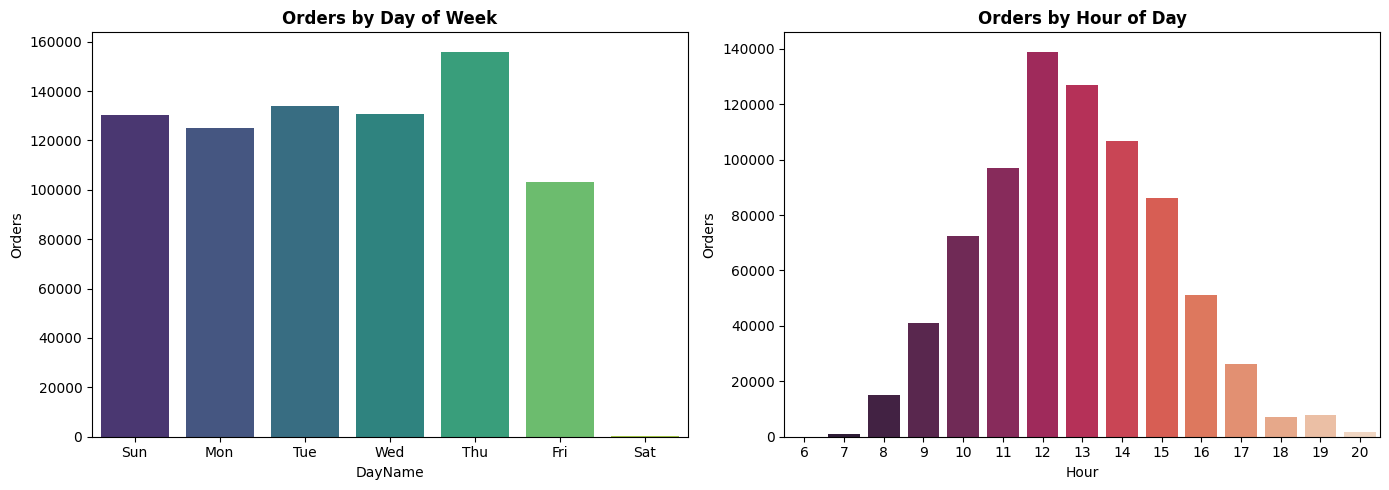

In [9]:
# Orders by day of week (1=Sun, 7=Sat in Spark)
dow = df.groupBy('DayOfWeek').agg(F.count('Invoice').alias('Orders')) \
    .orderBy('DayOfWeek').toPandas()
dow['DayName'] = ['Sun','Mon','Tue','Wed','Thu','Fri','Sat']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=dow, x='DayName', y='Orders', palette='viridis', ax=axes[0])
axes[0].set_title('Orders by Day of Week', fontweight='bold')

# Orders by hour
hour_df = df.groupBy('Hour').agg(F.count('Invoice').alias('Orders')) \
    .orderBy('Hour').toPandas()
sns.barplot(data=hour_df, x='Hour', y='Orders', palette='rocket', ax=axes[1])
axes[1].set_title('Orders by Hour of Day', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/time_patterns.png', dpi=150)
plt.show()

In [10]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml import Pipeline
import datetime

# Reference date for Recency
ref_date = df.agg(F.max('InvoiceDate')).collect()[0][0]

rfm = df.groupBy('Customer ID').agg(
    F.datediff(F.lit(ref_date), F.max('InvoiceDate')).alias('Recency'),
    F.countDistinct('Invoice').alias('Frequency'),
    F.sum('TotalPrice').alias('Monetary'),
    F.countDistinct('StockCode').alias('ProductDiversity')
)

rfm.show(5)

# Assemble features
assembler = VectorAssembler(
    inputCols=['Recency', 'Frequency', 'Monetary', 'ProductDiversity'],
    outputCol='features_raw'
)

scaler = StandardScaler(inputCol='features_raw', outputCol='features', withStd=True, withMean=True)
kmeans = KMeans(k=4, seed=42, featuresCol='features', predictionCol='cluster')

pipeline = Pipeline(stages=[assembler, scaler, kmeans])
model = pipeline.fit(rfm)
rfm_clustered = model.transform(rfm)

rfm_clustered.groupBy('cluster').agg(
    F.count('Customer ID').alias('Count'),
    F.round(F.avg('Recency'), 1).alias('Avg_Recency'),
    F.round(F.avg('Frequency'), 1).alias('Avg_Frequency'),
    F.round(F.avg('Monetary'), 2).alias('Avg_Monetary')
).orderBy('cluster').show()

+-----------+-------+---------+------------------+----------------+
|Customer ID|Recency|Frequency|          Monetary|ProductDiversity|
+-----------+-------+---------+------------------+----------------+
|      15727|     16|       15| 9371.710000000001|             426|
|      15957|     31|        3|            921.25|             121|
|      16503|    106|       11| 3614.340000000001|             161|
|      16386|     28|        3|1068.1599999999994|             127|
|      13285|     23|        6| 3364.589999999999|             182|
+-----------+-------+---------+------------------+----------------+
only showing top 5 rows
+-------+-----+-----------+-------------+------------+
|cluster|Count|Avg_Recency|Avg_Frequency|Avg_Monetary|
+-------+-----+-----------+-------------+------------+
|      0| 1968|      465.0|          2.1|      712.88|
|      1| 3403|       73.2|          5.3|     1899.58|
|      2|    9|        1.9|        216.8|   251172.99|
|      3|  498|       33.3|       

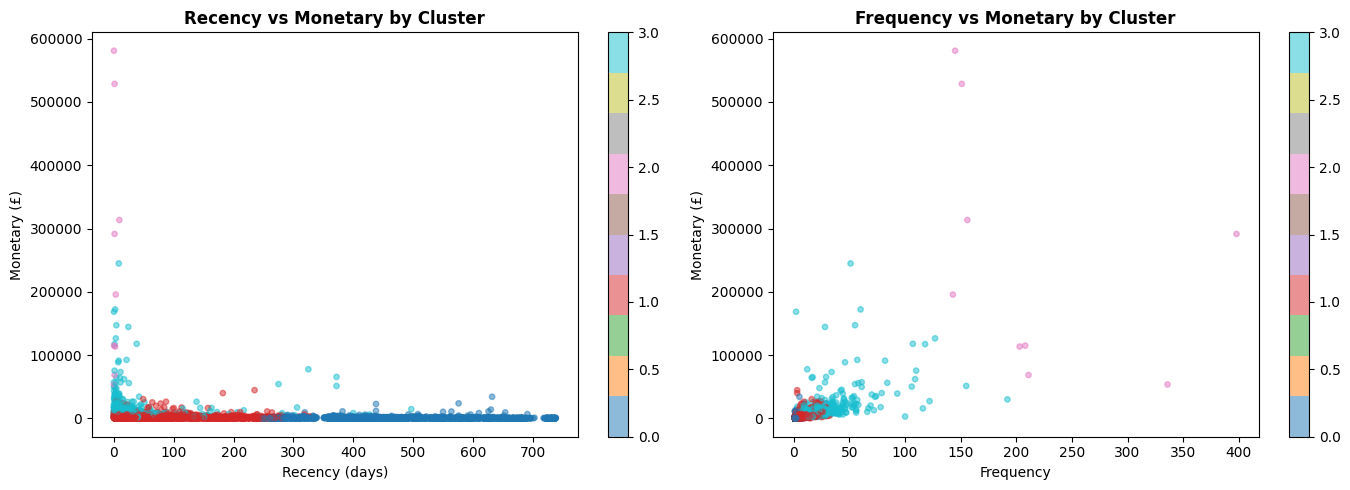

In [11]:
rfm_pd = rfm_clustered.select('Recency', 'Frequency', 'Monetary', 'cluster').toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter1 = axes[0].scatter(rfm_pd['Recency'], rfm_pd['Monetary'],
                            c=rfm_pd['cluster'], cmap='tab10', alpha=0.5, s=15)
axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Monetary (£)')
axes[0].set_title('Recency vs Monetary by Cluster', fontweight='bold')
plt.colorbar(scatter1, ax=axes[0])

scatter2 = axes[1].scatter(rfm_pd['Frequency'], rfm_pd['Monetary'],
                            c=rfm_pd['cluster'], cmap='tab10', alpha=0.5, s=15)
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Monetary (£)')
axes[1].set_title('Frequency vs Monetary by Cluster', fontweight='bold')
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/clusters.png', dpi=150)
plt.show()

In [12]:
from pyspark.ml.fpm import FPGrowth

# Build basket: one row per invoice with list of products
basket = df.groupBy('Invoice').agg(
    F.collect_set('StockCode').alias('items')
)

# Filter baskets with at least 2 items
basket = basket.filter(F.size('items') >= 2)

fp = FPGrowth(itemsCol='items', minSupport=0.02, minConfidence=0.3)
fpm = fp.fit(basket)

print("=== Frequent Itemsets ===")
fpm.freqItemsets.orderBy(F.desc('freq')).show(10, truncate=False)

print("=== Association Rules ===")
fpm.associationRules.orderBy(F.desc('lift')).show(10, truncate=False)

=== Frequent Itemsets ===
+--------+----+
|items   |freq|
+--------+----+
|[85123A]|4843|
|[22423] |3266|
|[85099B]|3229|
|[84879] |2641|
|[20725] |2578|
|[21212] |2507|
|[47566] |2053|
|[22383] |2004|
|[20727] |1993|
|[22382] |1919|
+--------+----+
only showing top 10 rows
=== Association Rules ===
+----------+----------+-------------------+------------------+--------------------+
|antecedent|consequent|confidence         |lift              |support             |
+----------+----------+-------------------+------------------+--------------------+
|[22699]   |[22697]   |0.7073170731707317 |25.37135114208285 |0.022243856388470956|
|[22697]   |[22699]   |0.7978835978835979 |25.371351142082847|0.022243856388470956|
|[22727]   |[22726]   |0.6136363636363636 |20.07763689013689 |0.020709797327197098|
|[22726]   |[22727]   |0.6776061776061776 |20.07763689013689 |0.020709797327197098|
|[22356]   |[20724]   |0.6344765342960289 |14.385853567245814|0.020739298462990826|
|[20724]   |[22356]   |0.47

In [13]:
from pyspark.ml.fpm import FPGrowth

# Build basket: one row per invoice with list of products
basket = df.groupBy('Invoice').agg(
    F.collect_set('StockCode').alias('items')
)

# Filter baskets with at least 2 items
basket = basket.filter(F.size('items') >= 2)

fp = FPGrowth(itemsCol='items', minSupport=0.02, minConfidence=0.3)
fpm = fp.fit(basket)

print("=== Frequent Itemsets ===")
fpm.freqItemsets.orderBy(F.desc('freq')).show(10, truncate=False)

print("=== Association Rules ===")
fpm.associationRules.orderBy(F.desc('lift')).show(10, truncate=False)

=== Frequent Itemsets ===
+--------+----+
|items   |freq|
+--------+----+
|[85123A]|4843|
|[22423] |3266|
|[85099B]|3229|
|[84879] |2641|
|[20725] |2578|
|[21212] |2507|
|[47566] |2053|
|[22383] |2004|
|[20727] |1993|
|[22382] |1919|
+--------+----+
only showing top 10 rows
=== Association Rules ===
+----------+----------+-------------------+------------------+--------------------+
|antecedent|consequent|confidence         |lift              |support             |
+----------+----------+-------------------+------------------+--------------------+
|[22699]   |[22697]   |0.7073170731707317 |25.37135114208285 |0.022243856388470956|
|[22697]   |[22699]   |0.7978835978835979 |25.371351142082847|0.022243856388470956|
|[22727]   |[22726]   |0.6136363636363636 |20.07763689013689 |0.020709797327197098|
|[22726]   |[22727]   |0.6776061776061776 |20.07763689013689 |0.020709797327197098|
|[22356]   |[20724]   |0.6344765342960289 |14.385853567245814|0.020739298462990826|
|[20724]   |[22356]   |0.47

In [17]:
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql import functions as F   # <-- FIXED
from pyspark.ml.feature import StringIndexer

# Build user-item matrix: implicit rating = log(total spend)
user_item = df.groupBy('Customer ID', 'StockCode').agg(
    F.sum('TotalPrice').alias('spend')
).withColumn('rating', F.log1p('spend'))

# Encode StockCode to integer index
indexer = StringIndexer(inputCol='StockCode', outputCol='item_index')
user_item = indexer.fit(user_item).transform(user_item)

# Cast columns to correct types
user_item = user_item.withColumn('item_index', F.col('item_index').cast('int'))
user_item = user_item.withColumnRenamed('Customer ID', 'user_id')
user_item = user_item.withColumn('user_id', F.col('user_id').cast('int'))

# Train-test split
train, test = user_item.randomSplit([0.8, 0.2], seed=42)

# ALS model
als = ALS(
    userCol='user_id',
    itemCol='item_index',
    ratingCol='rating',
    rank=20,
    maxIter=10,
    regParam=0.1,
    coldStartStrategy='drop',
    seed=42
)

# Train model
als_model = als.fit(train)

# Predictions
predictions = als_model.transform(test)

# Evaluation
evaluator = RegressionEvaluator(
    metricName='rmse',
    labelCol='rating',
    predictionCol='prediction'
)
rmse = evaluator.evaluate(predictions)
print(f"ALS RMSE: {rmse:.4f}")

evaluator_mae = RegressionEvaluator(
    metricName='mae',
    labelCol='rating',
    predictionCol='prediction'
)
mae = evaluator_mae.evaluate(predictions)
print(f"ALS MAE:  {mae:.4f}")

ALS RMSE: 0.6838
ALS MAE:  0.5038


In [18]:
# Top 5 product recommendations per user (sample 10 users)
user_recs = als_model.recommendForAllUsers(5)
user_recs.limit(10).show(truncate=False)

+-------+----------------------------------------------------------------------------------------------+
|user_id|recommendations                                                                               |
+-------+----------------------------------------------------------------------------------------------+
|12346  |[{1161, 6.9347124}, {3075, 5.6248865}, {4497, 5.2459774}, {768, 5.104937}, {161, 5.037339}]   |
|12347  |[{2473, 5.6665034}, {4357, 5.6580353}, {2904, 5.4780827}, {3852, 5.290439}, {2925, 5.2822247}]|
|12348  |[{2473, 6.8669586}, {2904, 6.804337}, {4357, 6.546665}, {3852, 6.4157267}, {3787, 6.3731976}] |
|12349  |[{202, 5.312168}, {4357, 5.297918}, {2925, 5.250182}, {2904, 5.244938}, {2473, 5.035079}]     |
|12350  |[{2473, 4.749935}, {2904, 4.5732136}, {4357, 4.4676948}, {4563, 4.433863}, {4353, 4.3997526}] |
|12353  |[{4357, 4.8250704}, {2473, 4.767614}, {2904, 4.693433}, {2925, 4.5279207}, {3852, 4.524418}]  |
|12355  |[{4357, 5.6348104}, {2925, 5.381804}, {2904, 5

/tmp/ipykernel_4236/824043898.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country, x='Country', y='Revenue', palette='coolwarm', ax=ax)


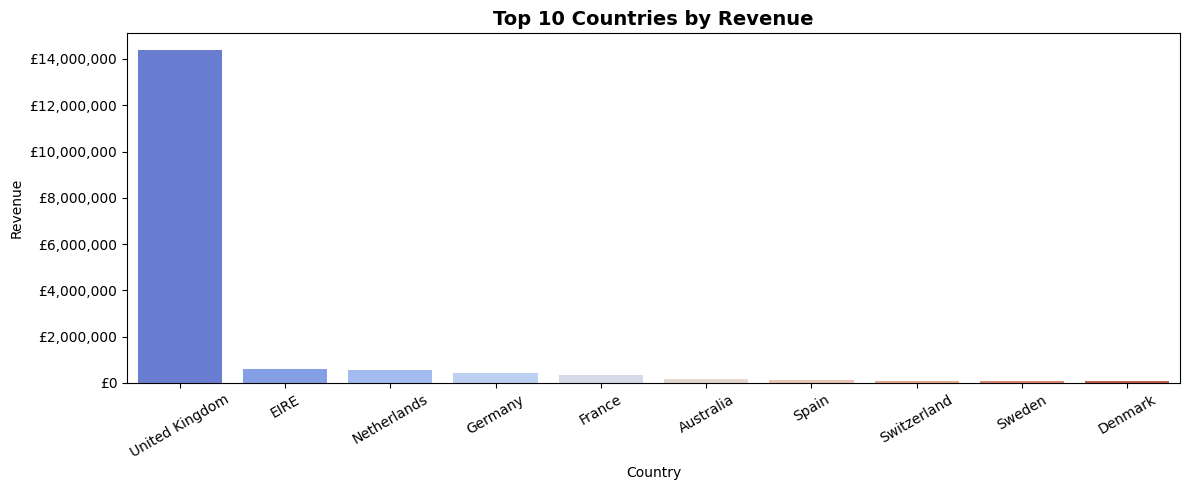

In [19]:
country = df.groupBy('Country').agg(F.sum('TotalPrice').alias('Revenue')) \
    .orderBy(F.desc('Revenue')).limit(10).toPandas()

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=country, x='Country', y='Revenue', palette='coolwarm', ax=ax)
ax.set_title('Top 10 Countries by Revenue', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/revenue_by_country.png', dpi=150)
plt.show()

In [20]:
# Save RFM clusters to CSV on Drive
rfm_clustered.toPandas().to_csv('/content/drive/MyDrive/rfm_clusters.csv', index=False)

# Save association rules to CSV
fpm.associationRules.toPandas().to_csv('/content/drive/MyDrive/association_rules.csv', index=False)

print("✅ All files saved to your Google Drive!")

✅ All files saved to your Google Drive!
